## Imports and setup

In [11]:
import os
import json
import sys
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # In Jupyter, __file__ usually doesn't exist
    NOTEBOOK_DIR = os.getcwd()

# If this notebook lives in "notebooks/", repo root is its parent
if os.path.basename(NOTEBOOK_DIR) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
else:
    # Fall back to "one level up" behavior
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add repo root so `from src...` imports work
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Run-specific results directory
RESULTS_ROOT = os.path.join(REPO_ROOT, "results")
RUN_ID = datetime.now().strftime("%Y-%m-%d_%H.%M.%S")
RUN_DIR = os.path.join(RESULTS_ROOT, "runs", RUN_ID)
FIG_DIR = os.path.join(RUN_DIR, "figures")

os.makedirs(FIG_DIR, exist_ok=True)
print("Saving this run to:", RUN_DIR)

from src.model3d import Small3DCNN
from src.train_utils import TrainConfig, set_seed, train_one_epoch, evaluate, evaluate_loss, save_json, save_checkpoint

# ----------- Saving locations -----------

# Saving location for metrics 
metrics_path = os.path.join(RUN_DIR, "metrics.json")

# Saving location for plots 
train_loss_path = os.path.join(FIG_DIR, f"train_loss_{RUN_ID}.png")
confusion_matrix_path = os.path.join(FIG_DIR, f"confusion_matrix_{RUN_ID}.png")
table_path = os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png")


Saving this run to: /Users/erem/Desktop/Desktop Folder/UBC/Fifth Year/Term 2/Cmpe 401/lung-nodule-3d/results/runs/2026-03-28_13.15.49


## Config and device

In [12]:
cfg = TrainConfig(
    epochs=50,
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=128,

    # In macOS notebooks, multiprocessing can break with custom collate_fn
    # Keeping num_workers=0 avoids worker spawn/pickling issues
    num_workers=0,

    # Seed is set for more repeatable runs
    seed=42,

    # Default decision threshold for converting probability -> class label
    threshold=0.5
)

# Use GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Set random seeds across libraries to reduce run-to-run variation
set_seed(cfg.seed)

# Save plots and figures into this folder
os.makedirs("results/figures", exist_ok=True)

device: cpu


## Load NoduleMNIST3D

In [13]:
data_flag = "nodulemnist3d"
info = INFO[data_flag]

# Dataset class name is stored as a string in INFO; fetch the class object
DataClass = getattr(medmnist, info["python_class"])

print("Task:", info["task"])
print("Labels:", info["label"])
print("Channels:", info["n_channels"])

# Some MedMNIST versions omit n_classes; fallback to the number of labels
n_classes = info.get("n_classes", len(info["label"]))
print("Num classes:", n_classes)

Task: binary-class
Labels: {'0': 'benign', '1': 'malignant'}
Channels: 1
Num classes: 2


## Dataset Splitting

In [14]:
# MedMNIST downloads automatically to its cache location when download=True
train_ds = DataClass(split="train", download=True)
val_ds   = DataClass(split="val", download=True)
test_ds  = DataClass(split="test", download=True)

# Quick check - dataset sizes should match expected counts
print("sizes:", len(train_ds), len(val_ds), len(test_ds))

sizes: 1158 165 310


Important note: MedMNIST labels are typically shaped (N, 1). We’ll flatten later.

## Handle class imbalance helper
### Using `pos_weight`

In [15]:
def get_label_array(ds):
    # ds[i] -> (x, y) where y is shape (1,)
    y = [int(np.array(ds[i][1]).reshape(-1)[0]) for i in range(len(ds))]
    return np.array(y, dtype=int)

y_train = get_label_array(train_ds)
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())

print("train positives:", n_pos, "train negatives:", n_neg)

# pos_weight = neg/pos is the standard weighting for BCEWithLogitsLoss
pos_weight_value = (n_neg / max(n_pos, 1))
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

print("pos_weight:", pos_weight_value)

train positives: 295 train negatives: 863
pos_weight: 2.925423728813559


## DataLoader

In [16]:
# collate_fn controls how a list of dataset samples becomes a batch
def collate_fn(batch, train=False):
    xs, ys = zip(*batch)

    x = torch.tensor(np.stack(xs)).float()
    y = torch.tensor(np.stack(ys)).long()

    # Ensure x is (B, 1, D, H, W)
    if x.ndim == 4:
        x = x.unsqueeze(1)

    # ---- Normalization (per-volume standardization) ----
    # Standardize each sample independently: (x - mean) / std
    # This stabilizes training when intensity scales vary.
    eps = 1e-6
    mean = x.mean(dim=(2, 3, 4), keepdim=True)
    std = x.std(dim=(2, 3, 4), keepdim=True)
    x = (x - mean) / (std + eps)

    # ---- Lightweight 3D augmentation (train only) ----
    if train:
        # Random flips along each axis (depth/height/width)
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])  # flip depth
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[3])  # flip height
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[4])  # flip width

        # Small gaussian noise
        if torch.rand(1).item() < 0.3:
            x = x + 0.05 * torch.randn_like(x)

    return x, y

# pin_memory only helps when using CUDA; on CPU it can be left False
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=True)
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False)
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False)
)

## Data Visualization

x0 shape: (1, 28, 28, 28) y0: [0]


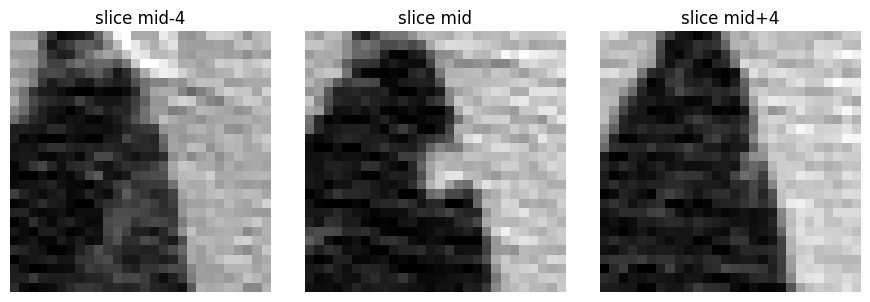

batch shapes: torch.Size([128, 1, 28, 28, 28]) torch.Size([128, 1])


In [17]:
# Inspect a single sample to confirm shapes and label format
x0, y0 = train_ds[0]
x0 = np.array(x0)
print("x0 shape:", x0.shape, "y0:", y0)

# For plotting, drop the channel dimension if present: (1, D, H, W) -> (D, H, W)
vol = x0[0] if x0.ndim == 4 else x0
mid = vol.shape[0] // 2

# Plot a few slices around the center depth
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(vol[mid-4], cmap="gray"); axes[0].set_title("slice mid-4"); axes[0].axis("off")
axes[1].imshow(vol[mid],   cmap="gray"); axes[1].set_title("slice mid");   axes[1].axis("off")
axes[2].imshow(vol[mid+4], cmap="gray"); axes[2].set_title("slice mid+4"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Confirm the DataLoader batch matches the 3D CNN expectation
xb, yb = next(iter(train_loader))
print("batch shapes:", xb.shape, yb.shape)

## Case Examples: Benign vs Malignant

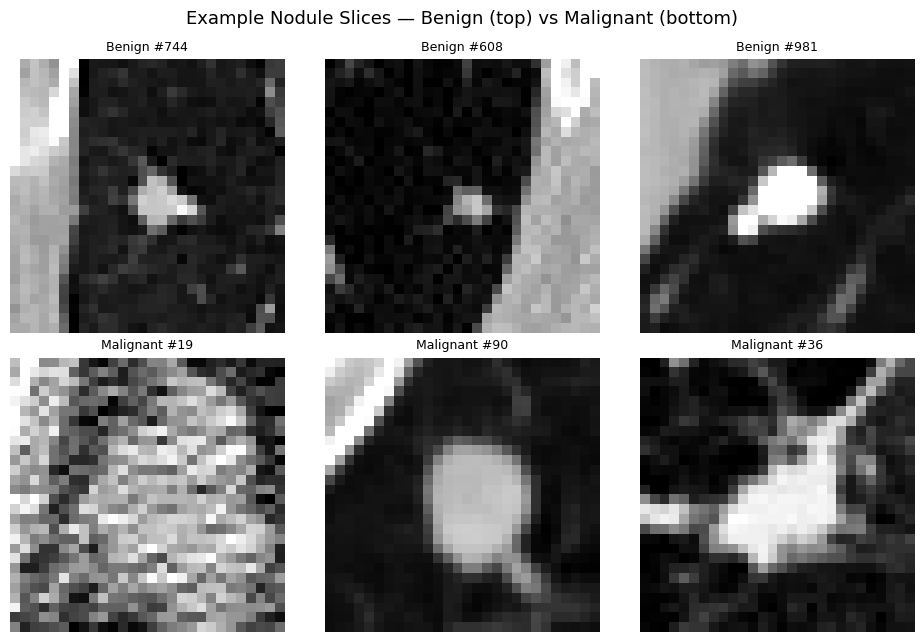

In [18]:
# Representative slices for each class

def show_class_examples(ds, n_per_class=3, seed=0):
    rng = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    benign_idx    = np.where(y_all == 0)[0]
    malignant_idx = np.where(y_all == 1)[0]

    chosen_b = rng.choice(benign_idx,    size=n_per_class, replace=False)
    chosen_m = rng.choice(malignant_idx, size=n_per_class, replace=False)

    fig, axes = plt.subplots(
        2, n_per_class, figsize=(n_per_class * 3.2, 6.5)
    )
    fig.suptitle("Example Nodule Slices — Benign (top) vs Malignant (bottom)", fontsize=13)

    for col, idx in enumerate(chosen_b):
        vol = np.array(ds[idx][0])            # (1, 28, 28, 28) or (28,28,28)
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[0, col].imshow(vol[mid], cmap="gray")
        axes[0, col].set_title(f"Benign #{idx}", fontsize=9)
        axes[0, col].axis("off")

    for col, idx in enumerate(chosen_m):
        vol = np.array(ds[idx][0])
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[1, col].imshow(vol[mid], cmap="gray")
        axes[1, col].set_title(f"Malignant #{idx}", fontsize=9)
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"case_examples_{RUN_ID}.png"), dpi=200)
    plt.show()

show_class_examples(train_ds, n_per_class=3)

## Model, Loss, and Optimizer

In [19]:
# Model outputs a single logit for binary classification
model = Small3DCNN(dropout_p=0.3).to(device)

# BCEWithLogitsLoss expects raw logits
# Accounting for class imbalance to improve recall score
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# AdamW is a stable default for this small CNN baseline
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

# Optimizer Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",       # want to maximize AUROC
    factor=0.5,       # reduce LR by half
    patience=3,       # wait 3 epochs without improvement
    min_lr=1e-6
)

print("num params:", sum(p.numel() for p in model.parameters()))

num params: 883601


## Training loop

In [20]:
# Store training loss and validation metrics per epoch
history = {"train_loss": [], "val_loss": [], "val": []}
best_score = -1.0
best_epoch = -1

for epoch in range(1, cfg.epochs + 1):
    # One full pass over the training set
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Evaluate for validation loss (real BCE loss)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    # Evaluate on validation set at the current threshold
    val_metrics = evaluate(model, val_loader, device, threshold=cfg.threshold, criterion=criterion)
    val_metrics["val_loss"] = val_loss

    # Step the scheduler using validation AUROC
    score_for_sched = val_metrics["auroc"] if val_metrics["auroc"] is not None else val_metrics["f1"]
    scheduler.step(score_for_sched)

    print("lr:", optimizer.param_groups[0]["lr"])

    # Log metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val"].append(val_metrics)

    print(
        f"epoch {epoch:02d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
        f"val auroc {val_metrics['auroc']} | val f1 {val_metrics['f1']:.4f}"
    )

    # Saving location for results 
    best_ckpt_path = os.path.join(RUN_DIR, "best.pt")
    # prefer AUROC when available; fallback to F1
    score = val_metrics["auroc"] if val_metrics["auroc"] is not None else val_metrics["f1"]
    if score > best_score:
        best_score = score
        best_epoch = epoch
        save_checkpoint(
            best_ckpt_path,
            model,
            optimizer,
            epoch,
            {"val_metrics": val_metrics, "config": cfg.__dict__},
        )

# Save training history and the best epoch so results are reproducible
save_json(metrics_path, {"history": history, "best_epoch": best_epoch})
print("best_epoch:", best_epoch, "best_score:", best_score)

lr: 0.0003
epoch 01 | train_loss 0.8571 | val_loss 0.9893 | val auroc 0.7154471544715447 | val f1 0.1509


lr: 0.0003
epoch 02 | train_loss 0.7674 | val_loss 0.7786 | val auroc 0.8054587688734031 | val f1 0.6067


lr: 0.0003
epoch 03 | train_loss 0.7136 | val_loss 0.9604 | val auroc 0.7822299651567943 | val f1 0.4557


lr: 0.0003
epoch 04 | train_loss 0.8506 | val_loss 0.8157 | val auroc 0.8184281842818428 | val f1 0.6286


lr: 0.0003
epoch 05 | train_loss 0.7097 | val_loss 0.6790 | val auroc 0.8221060782036392 | val f1 0.6226


...

lr: 1e-06
epoch 46 | train_loss 0.6210 | val_loss 0.6234 | val auroc 0.8383662408052651 | val f1 0.7033


lr: 1e-06
epoch 47 | train_loss 0.6795 | val_loss 0.6283 | val auroc 0.8354626403406891 | val f1 0.7126


lr: 1e-06
epoch 48 | train_loss 0.5951 | val_loss 0.6284 | val auroc 0.8356562137049942 | val f1 0.7045


lr: 1e-06
epoch 49 | train_loss 0.6098 | val_loss 0.6271 | val auroc 0.8368176538908247 | val f1 0.7126


lr: 1e-06
epoch 50 | train_loss 0.5973 | val_loss 0.6372 | val auroc 0.8354626403406891 | val f1 0.7250
best_epoch: 6 best_score: 0.8435927216415021


## Intermediate Feature Map Visualization

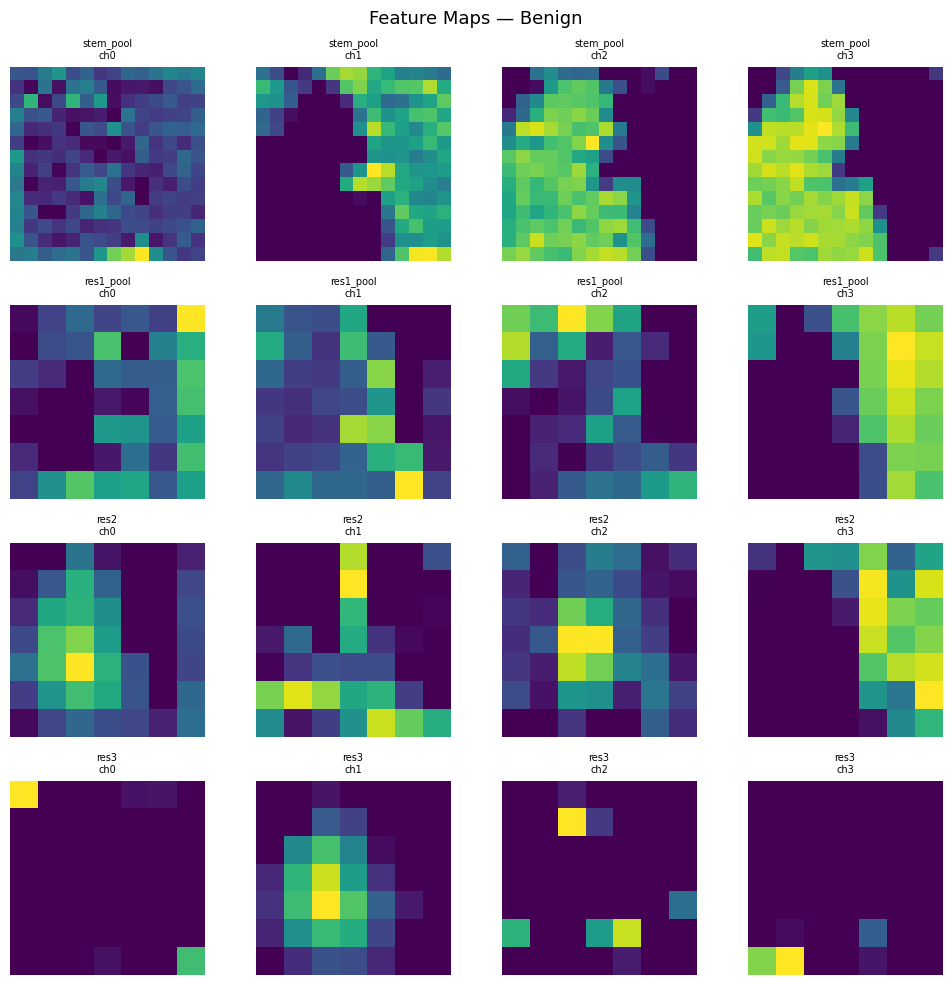

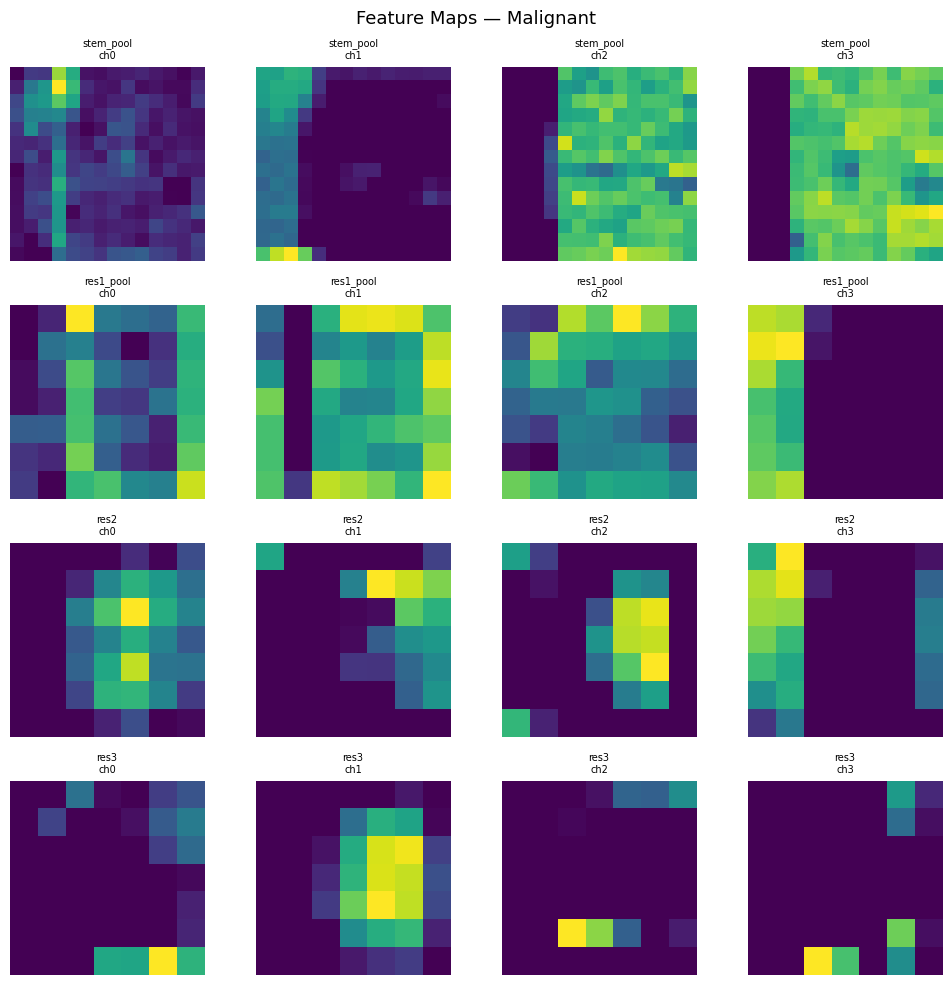

In [21]:
# Pick one benign and one malignant sample, run a forward pass,
# and display the first few channels of each residual stage.

def visualize_feature_maps(model, ds, device, n_channels=4):
    model.eval()
    y_all = get_label_array(ds)

    # pick first benign and first malignant
    idx_b = int(np.where(y_all == 0)[0][0])
    idx_m = int(np.where(y_all == 1)[0][0])

    for label_name, idx in [("Benign", idx_b), ("Malignant", idx_m)]:
        x_raw = np.array(ds[idx][0]).astype(np.float32)
        x_t   = torch.tensor(x_raw).unsqueeze(0)         # (1, 1, 28, 28, 28)
        if x_t.ndim == 4:
            x_t = x_t.unsqueeze(0)

        # Normalise the same way as collate_fn
        eps = 1e-6
        x_t = (x_t - x_t.mean()) / (x_t.std() + eps)
        x_t = x_t.to(device)

        with torch.no_grad():
            maps = model.get_feature_maps(x_t)

        stage_names = list(maps.keys())
        fig, axes = plt.subplots(
            len(stage_names), n_channels,
            figsize=(n_channels * 2.5, len(stage_names) * 2.5)
        )
        fig.suptitle(f"Feature Maps — {label_name}", fontsize=13)

        for row, sname in enumerate(stage_names):
            fmap = maps[sname][0]        # (C, D, H, W) – drop batch dim
            mid_d = fmap.shape[1] // 2  # middle depth slice
            for col in range(n_channels):
                ax = axes[row, col] if len(stage_names) > 1 else axes[col]
                ch_map = fmap[col, mid_d].numpy()
                ax.imshow(ch_map, cmap="viridis")
                ax.set_title(f"{sname}\nch{col}", fontsize=7)
                ax.axis("off")

        plt.tight_layout()
        plt.savefig(
            os.path.join(FIG_DIR, f"feature_maps_{label_name.lower()}_{RUN_ID}.png"),
            dpi=200
        )
        plt.show()

visualize_feature_maps(model, train_ds, device, n_channels=4)

## Tuning Decision Threshold

In [22]:
# Collect logits and labels from a loader (used for threshold tuning)
@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x).cpu().numpy()
        all_logits.append(logits)

        # Labels arrive as shape (B, 1); flatten to (B,)
        all_y.append(y.numpy().reshape(-1))
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

# Use validation set to choose a threshold (instead of guessing 0.5)
y_val, logits_val = get_logits_and_labels(model, val_loader, device)

from src.metrics import compute_binary_metrics

# Sweep thresholds and select the one that maximizes F1 on validation
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
best = None

for t in thresholds:
    m = compute_binary_metrics(y_val, logits_val, threshold=float(t))
    row = (t, m["f1"], m["recall"], m["precision"], m["specificity"], m["accuracy"], m["auroc"])
    rows.append(row)
    
    # Track best threshold by F1 score
    if best is None or m["f1"] > best[1]:
        best = row

print("best by F1:", best)

best by F1: (np.float64(0.49999999999999994), 0.725, 0.6904761904761905, 0.7631578947368421, 0.926829268292683, 0.8666666666666667, 0.8354626403406891)


## Plot training curve

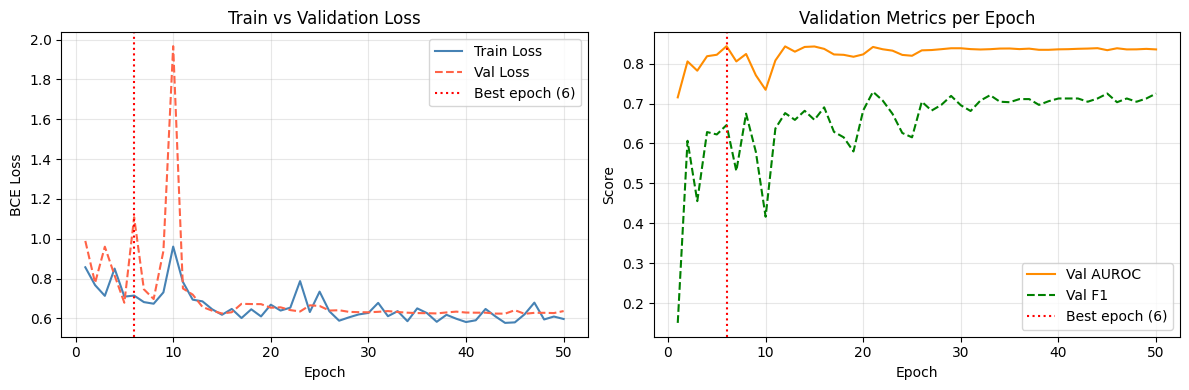

In [23]:
train_losses = history["train_loss"]
val_losses   = history["val_loss"]
val_aurocs   = [v["auroc"] for v in history["val"]]
val_f1s      = [v["f1"]    for v in history["val"]]

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---- Left: Train + Val Loss ----
axes[0].plot(epochs_range, train_losses, label="Train Loss", color="steelblue")
axes[0].plot(epochs_range, val_losses,   label="Val Loss",   color="tomato", linestyle="--")
axes[0].axvline(best_epoch, color="red", linestyle=":", label=f"Best epoch ({best_epoch})")
axes[0].set_title("Train vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- Right: Validation AUROC + F1 ----
axes[1].plot(epochs_range, val_aurocs, label="Val AUROC", color="darkorange")
axes[1].plot(epochs_range, val_f1s,   label="Val F1",    color="green", linestyle="--")
axes[1].axvline(best_epoch, color="red", linestyle=":", label=f"Best epoch ({best_epoch})")
axes[1].set_title("Validation Metrics per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"train_val_curves_{RUN_ID}.png"), dpi=200)
plt.show()

## Test evaluation 
### With default threshold and write into metrics.json

In [24]:
# Evaluate test set using the default threshold (0.5 unless changed)
test_metrics = evaluate(model, test_loader, device, threshold=cfg.threshold)
print(test_metrics)

# Store metrics in the same JSON file as training history
with open(metrics_path, "r") as f:
    m = json.load(f)
m["test_default_threshold"] = test_metrics
with open(metrics_path, "w") as f:
    json.dump(m, f, indent=2)

{'auroc': 0.8944359756097561, 'f1': 0.6266666666666667, 'accuracy': 0.8193548387096774, 'precision': 0.5465116279069767, 'recall': 0.734375, 'specificity': 0.8414634146341463, 'confusion_matrix': [[207, 39], [17, 47]]}


## Confusion matrix figure

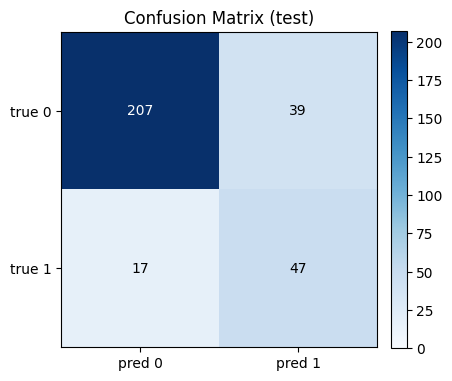

In [25]:
cm = np.array(test_metrics["confusion_matrix"])

plt.figure(figsize=(4.6, 4.2))
im = plt.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
plt.colorbar(im, fraction=0.046, pad=0.04)

# Label mapping for this dataset:
#   0 -> benign  (negative class)
#   1 -> malignant (positive class)

plt.title("Confusion Matrix (test)")
plt.xticks([0, 1], ["pred 0", "pred 1"])
plt.yticks([0, 1], ["true 0", "true 1"])

# text color that stays readable
thresh = cm.max() * 0.6
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        txt_color = "white" if val > thresh else "black"
        plt.text(j, i, str(val), ha="center", va="center", color=txt_color)

plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=200)
plt.show()

## Threshold tuning on validation set

In [26]:
# Recompute best threshold in a structured dict format for saving
@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()  # eval mode for consistent inference (no dropout, BN uses running stats)

    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)                     # move batch to CPU/GPU
        logits = model(x).cpu().numpy()       # forward pass -> raw logits (B,)
        all_logits.append(logits)

        all_y.append(y.numpy().reshape(-1))   # labels often come as (B,1); flatten to (B,)

    # combine batches into full arrays for the whole split
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

# get validation labels + logits once, then sweep thresholds cheaply
y_val, logits_val = get_logits_and_labels(model, val_loader, device)

# try a range of thresholds; pick the one that maximizes F1 on validation
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
best = None

for t in thresholds:
    met = compute_binary_metrics(y_val, logits_val, threshold=float(t))  # metrics at this threshold
    row = {
        "threshold": float(t),
        "f1": met["f1"],
        "recall": met["recall"],
        "precision": met["precision"],
        "specificity": met["specificity"],
        "accuracy": met["accuracy"],
        "auroc": met["auroc"],
    }
    rows.append(row)

    if best is None or row["f1"] > best["f1"]:
        best = row

print("best threshold by F1:", best)


best threshold by F1: {'threshold': 0.49999999999999994, 'f1': 0.725, 'recall': 0.6904761904761905, 'precision': 0.7631578947368421, 'specificity': 0.926829268292683, 'accuracy': 0.8666666666666667, 'auroc': 0.8354626403406891}


## Test evaluation with tuned threshold

In [27]:
# evaluate test set once using the chosen threshold
best_threshold = best["threshold"]
test_metrics_tuned = evaluate(model, test_loader, device, threshold=best_threshold)
print("threshold:", best_threshold)
print(test_metrics_tuned)

# write tuned-threshold results into the metrics.json file
with open(metrics_path, "r") as f:
    m = json.load(f)
m["best_threshold_val_f1"] = best
m["test_tuned_threshold"] = test_metrics_tuned
with open(metrics_path, "w") as f:
    json.dump(m, f, indent=2)

threshold: 0.49999999999999994
{'auroc': 0.8944359756097561, 'f1': 0.6266666666666667, 'accuracy': 0.8193548387096774, 'precision': 0.5465116279069767, 'recall': 0.734375, 'specificity': 0.8414634146341463, 'confusion_matrix': [[207, 39], [17, 47]]}


## Logistic regression baseline 
### With flattened voxels

In [28]:
def flatten_dataset(ds):
    X, y = [], []
    for i in range(len(ds)):
        x_i, y_i = ds[i]
        x_i = np.array(x_i).astype(np.float32)  # expected (1, 28, 28, 28)
        X.append(x_i.reshape(-1))               # flatten -> (28*28*28,)

        y.append(int(np.array(y_i).reshape(-1)[0]))  # label stored as (1,); convert to int

    return np.stack(X), np.array(y)

# build feature matrices for each split
X_train, y_train = flatten_dataset(train_ds)
X_val_lr, y_val_lr = flatten_dataset(val_ds)
X_test, y_test = flatten_dataset(test_ds)

# standardize features + train class-weighted logistic regression
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)
clf.fit(X_train, y_train)

# decision_function gives raw scores (logit-like) suitable for AUROC + thresholding
logits_test_lr = clf.decision_function(X_test)
lr_metrics = compute_binary_metrics(y_test, logits_test_lr, threshold=0.5)
print(lr_metrics)

# save baseline results into metrics.json
with open(metrics_path, "r") as f:
    m = json.load(f)
m["logreg_baseline_test"] = lr_metrics
with open(metrics_path, "w") as f:
    json.dump(m, f, indent=2)

{'auroc': 0.8226626016260161, 'f1': 0.5538461538461539, 'accuracy': 0.8129032258064516, 'precision': 0.5454545454545454, 'recall': 0.5625, 'specificity': 0.8780487804878049, 'confusion_matrix': [[216, 30], [28, 36]]}


## Results summary table

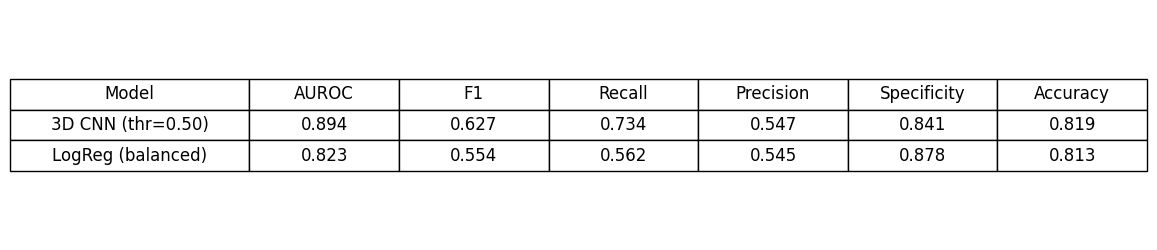

In [31]:
# Helper to format metric values for display in the table
def fmt(v):
    if v is None:
        return "N/A"
    return f"{v:.3f}"

def row_from_metrics(name, met):
    return [
        name,
        met.get("auroc", None),
        met.get("f1", None),
        met.get("recall", None),
        met.get("precision", None),
        met.get("specificity", None),
        met.get("accuracy", None),
    ]

rows_table = [
    row_from_metrics(f"3D CNN (thr={best_threshold:.2f})", test_metrics_tuned),
    row_from_metrics("LogReg (balanced)", lr_metrics),
]

col_labels = ["Model", "AUROC", "F1", "Recall", "Precision", "Specificity", "Accuracy"]
cell_text = [[r[0]] + [fmt(v) for v in r[1:]] for r in rows_table]


fig, ax = plt.subplots(figsize=(12, 2.6))  # wider + a bit taller
ax.axis("off")

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)

# Bigger text + bigger cells
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.25, 1.6)   # (x scale, y scale)

# Optional: make the first column wider (model names)
# This is a simple manual tweak that usually looks better.
for (r, c), cell in table.get_celld().items():
    if c == 0:
        cell.set_width(cell.get_width() * 1.6)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png"), dpi=300)
plt.show()


